# Modeling

Trains Logistic Regression, XGBoost, and LightGBM on each version of the training data from the preprocessing notebook, compares them, then looks at the cost of false negatives vs false positives and tunes the decision threshold.

In [1]:
#loading and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score,
    matthews_corrcoef
)


c:\Users\lenovo\Downloads\ecommerce-demand-forecasting\ecommerce-demand-forecasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#mlflow setup
mlflow.set_experiment("Credit_Fraud_Detection")

2026/08/12 15:20:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/12 15:20:31 INFO mlflow.store.db.utils: Updating database tables
2026/08/12 15:20:36 INFO mlflow.tracking.fluent: Experiment with name 'Credit_Fraud_Detection' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/lenovo/Downloads/Credit_Fraud_Detection/Credit_Fraud_Detection/notebooks/mlruns/1', creation_time=1786537236796, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786537236796, lifecycle_stage='active', name='Credit_Fraud_Detection', tags={}, trace_location=None, workspace='default'>

Loading the test set. This stays the same across all models, only the training data changes.

In [3]:
#load test set
X_test=pd.read_csv("../data/X_test.csv")
y_test=pd.read_csv("../data/y_test.csv").squeeze()
print(f"Test set: {X_test.shape}")
print(f"Test fraud rate: {y_test.mean()*100:.4f}%")

Test set: (56746, 27)
Test fraud rate: 0.1674%


Evaluation function, computes the metrics that matter for imbalanced fraud data and logs them to MLflow.

In [4]:
# Evaluation function
def evaluate_model(name,model,X_test,y_test,log_mlflow=True):
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]
    metrics={
        "recall":recall_score(y_test,y_pred),
        "precision":precision_score(y_test,y_pred),
        "f1":f1_score(y_test,y_pred),
        "mcc":matthews_corrcoef(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_prob),
        'auc_pr':    average_precision_score(y_test, y_prob)
    }
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred).ravel()
   

    metrics.update({'tn': int(tn), 'fp': int(fp), 
                'fn': int(fn), 'tp': int(tp)})
    #log to mlflow
    if log_mlflow:
        with mlflow.start_run(run_name=name):
            mlflow.log_metrics({k:v for k,v in metrics.items()
                               if k in ['recall', 'precision', 'f1',
                                       'auc_roc', 'auc_pr', 'mcc'] })
    # Print results
    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"{'='*55}")
    print(f"Recall:     {metrics['recall']:.4f}  <- fraud caught")
    print(f"Precision:  {metrics['precision']:.4f}  <- alert accuracy")
    print(f"F1:         {metrics['f1']:.4f}")
    print(f"AUC-ROC:    {metrics['auc_roc']:.4f}")
    print(f"AUC-PR:     {metrics['auc_pr']:.4f}  <- most important for imbalanced data")
    print(f"MCC:        {metrics['mcc']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:,}  (legitimate correctly identified)")
    print(f"  False Positives: {fp:,}  (legitimate wrongly flagged)")
    print(f"  False Negatives: {fn:,}  (fraud MISSED) <- most costly")
    print(f"  True Positives:  {tp:,}  (fraud correctly caught)")

    return metrics

Loading all four training set versions from preprocessing: no sampling, SMOTE, undersampling, and SMOTETomek.

In [5]:
# Load training data with all sampling variants
datasets = {
    'Original': (
        pd.read_csv('../data/X_train.csv'),
        pd.read_csv('../data/y_train.csv').squeeze()
    ),
    'SMOTE': (
        pd.read_csv('../data/X_train_smote.csv'),
        pd.read_csv('../data/y_train_smote.csv').squeeze()
    ),
    'Undersampling': (
        pd.read_csv('../data/X_train_under.csv'),
        pd.read_csv('../data/y_train_under.csv').squeeze()
    ),
    'SMOTETomek': (
        pd.read_csv('../data/X_train_combined.csv'),
        pd.read_csv('../data/y_train_combined.csv').squeeze()
    )
}


for name,(x,y) in datasets.items():
    print(f"{name}:{x.shape},fraud_rate:{y.mean()*100:.2f}%")

Original:(226980, 27),fraud_rate:0.17%
SMOTE:(453204, 27),fraud_rate:50.00%
Undersampling:(1134, 27),fraud_rate:33.33%
SMOTETomek:(453204, 27),fraud_rate:50.00%


Logistic Regression baseline, trained on each sampling version.

In [6]:
# Logistic Regression Baseline ---> train on all training data sets variants
all_results = {}
for sampling_name, (X_train_v, y_train_v) in datasets.items():
    model=LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_v, y_train_v)
    name = f"LogReg_{sampling_name}"
    metrics=evaluate_model(name,model, X_test, y_test)
    all_results[name]=metrics


Model: LogReg_Original
Recall:     0.8737  <- fraud caught
Precision:  0.0614  <- alert accuracy
F1:         0.1148
AUC-ROC:    0.9657
AUC-PR:     0.6540  <- most important for imbalanced data
MCC:        0.2283

Confusion Matrix:
  True Negatives:  55,383  (legitimate correctly identified)
  False Positives: 1,268  (legitimate wrongly flagged)
  False Negatives: 12  (fraud MISSED) <- most costly
  True Positives:  83  (fraud correctly caught)

Model: LogReg_SMOTE
Recall:     0.8737  <- fraud caught
Precision:  0.0568  <- alert accuracy
F1:         0.1067
AUC-ROC:    0.9607
AUC-PR:     0.6593  <- most important for imbalanced data
MCC:        0.2192

Confusion Matrix:
  True Negatives:  55,273  (legitimate correctly identified)
  False Positives: 1,378  (legitimate wrongly flagged)
  False Negatives: 12  (fraud MISSED) <- most costly
  True Positives:  83  (fraud correctly caught)

Model: LogReg_Undersampling
Recall:     0.8737  <- fraud caught
Precision:  0.0553  <- alert accuracy
F1

XGBoost, trained on each sampling version. For the original (no sampling) data, class weights are used instead of scale_pos_weight.

In [7]:
# XGBoost
for sampling_name, (X_train, y_train) in datasets.items():

    # Use class weights for original -->(no sampling)
    scale_pos = (y_train==0).sum() / (y_train==1).sum()

    model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos if sampling_name=='Original' else 1,
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr',
        verbosity=0
    )
    model.fit(X_train, y_train)

    name = f"XGB_{sampling_name}"
    metrics = evaluate_model(name, model, X_test, y_test)
    all_results[name] = metrics



Model: XGB_Original
Recall:     0.7895  <- fraud caught
Precision:  0.9036  <- alert accuracy
F1:         0.8427
AUC-ROC:    0.9748
AUC-PR:     0.8183  <- most important for imbalanced data
MCC:        0.8444

Confusion Matrix:
  True Negatives:  56,643  (legitimate correctly identified)
  False Positives: 8  (legitimate wrongly flagged)
  False Negatives: 20  (fraud MISSED) <- most costly
  True Positives:  75  (fraud correctly caught)

Model: XGB_SMOTE
Recall:     0.8000  <- fraud caught
Precision:  0.5507  <- alert accuracy
F1:         0.6524
AUC-ROC:    0.9698
AUC-PR:     0.8034  <- most important for imbalanced data
MCC:        0.6631

Confusion Matrix:
  True Negatives:  56,589  (legitimate correctly identified)
  False Positives: 62  (legitimate wrongly flagged)
  False Negatives: 19  (fraud MISSED) <- most costly
  True Positives:  76  (fraud correctly caught)

Model: XGB_Undersampling
Recall:     0.8526  <- fraud caught
Precision:  0.1224  <- alert accuracy
F1:         0.2140

LightGBM, trained on each sampling version, same setup as XGBoost.

In [8]:
# LightGBM
for sampling_name, (X_train, y_train) in datasets.items():
    # Use class weights for original -->(no sampling)
    scale_pos = (y_train==0).sum() / (y_train==1).sum()

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        scale_pos_weight=scale_pos if sampling_name=='Original' else 1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)

    name = f"LGB_{sampling_name}"
    metrics = evaluate_model(name, model, X_test, y_test)
    all_results[name] = metrics


Model: LGB_Original
Recall:     0.7263  <- fraud caught
Precision:  0.0447  <- alert accuracy
F1:         0.0842
AUC-ROC:    0.8501
AUC-PR:     0.0329  <- most important for imbalanced data
MCC:        0.1760

Confusion Matrix:
  True Negatives:  55,177  (legitimate correctly identified)
  False Positives: 1,474  (legitimate wrongly flagged)
  False Negatives: 26  (fraud MISSED) <- most costly
  True Positives:  69  (fraud correctly caught)

Model: LGB_SMOTE
Recall:     0.8211  <- fraud caught
Precision:  0.5200  <- alert accuracy
F1:         0.6367
AUC-ROC:    0.9670
AUC-PR:     0.8040  <- most important for imbalanced data
MCC:        0.6527

Confusion Matrix:
  True Negatives:  56,579  (legitimate correctly identified)
  False Positives: 72  (legitimate wrongly flagged)
  False Negatives: 17  (fraud MISSED) <- most costly
  True Positives:  78  (fraud correctly caught)

Model: LGB_Undersampling
Recall:     0.8526  <- fraud caught
Precision:  0.1044  <- alert accuracy
F1:         0.

Comparing every model and sampling combination, sorted by AUC-PR since that is the most informative metric for this level of class imbalance.

In [9]:
#comparison dataframe
results_df = pd.DataFrame(all_results).T
results_df = results_df.astype(float)

metric_cols = ['recall', 'precision', 'f1', 'auc_pr', 'auc_roc', 'mcc']
extra_cols = [c for c in ['fn', 'fp', 'tn', 'tp'] if c in results_df.columns]
results_df = results_df[metric_cols + extra_cols]

# Sort by AUC-PR
results_df = results_df.sort_values('auc_pr', ascending=False)

print("\n" + "="*80)
print("FULL MODEL COMPARISON - Sorted by AUC-PR")
print("="*80)
print(results_df.round(4).to_string())

# Best model
best_model = results_df.index[0]
print(f"\n Best model: {best_model}")
print(f"   AUC-PR:  {results_df.loc[best_model, 'auc_pr']:.4f}")
print(f"   Recall:  {results_df.loc[best_model, 'recall']:.4f}")

if 'fn' in results_df.columns:
    print(f"   FN:      {int(results_df.loc[best_model, 'fn'])} frauds missed")


FULL MODEL COMPARISON - Sorted by AUC-PR
                      recall  precision      f1  auc_pr  auc_roc     mcc    fn      fp       tn    tp
XGB_Original          0.7895     0.9036  0.8427  0.8183   0.9748  0.8444  20.0     8.0  56643.0  75.0
LGB_SMOTE             0.8211     0.5200  0.6367  0.8040   0.9670  0.6527  17.0    72.0  56579.0  78.0
LGB_SMOTETomek        0.8211     0.5200  0.6367  0.8040   0.9670  0.6527  17.0    72.0  56579.0  78.0
XGB_SMOTE             0.8000     0.5507  0.6524  0.8034   0.9698  0.6631  19.0    62.0  56589.0  76.0
XGB_SMOTETomek        0.8000     0.5507  0.6524  0.8034   0.9698  0.6631  19.0    62.0  56589.0  76.0
LGB_Undersampling     0.8526     0.1044  0.1860  0.7155   0.9758  0.2958  14.0   695.0  55956.0  81.0
XGB_Undersampling     0.8526     0.1224  0.2140  0.7140   0.9825  0.3207  14.0   581.0  56070.0  81.0
LogReg_SMOTE          0.8737     0.0568  0.1067  0.6593   0.9607  0.2192  12.0  1378.0  55273.0  83.0
LogReg_SMOTETomek     0.8737     0.0568 

Plotting the comparison across the main metrics.

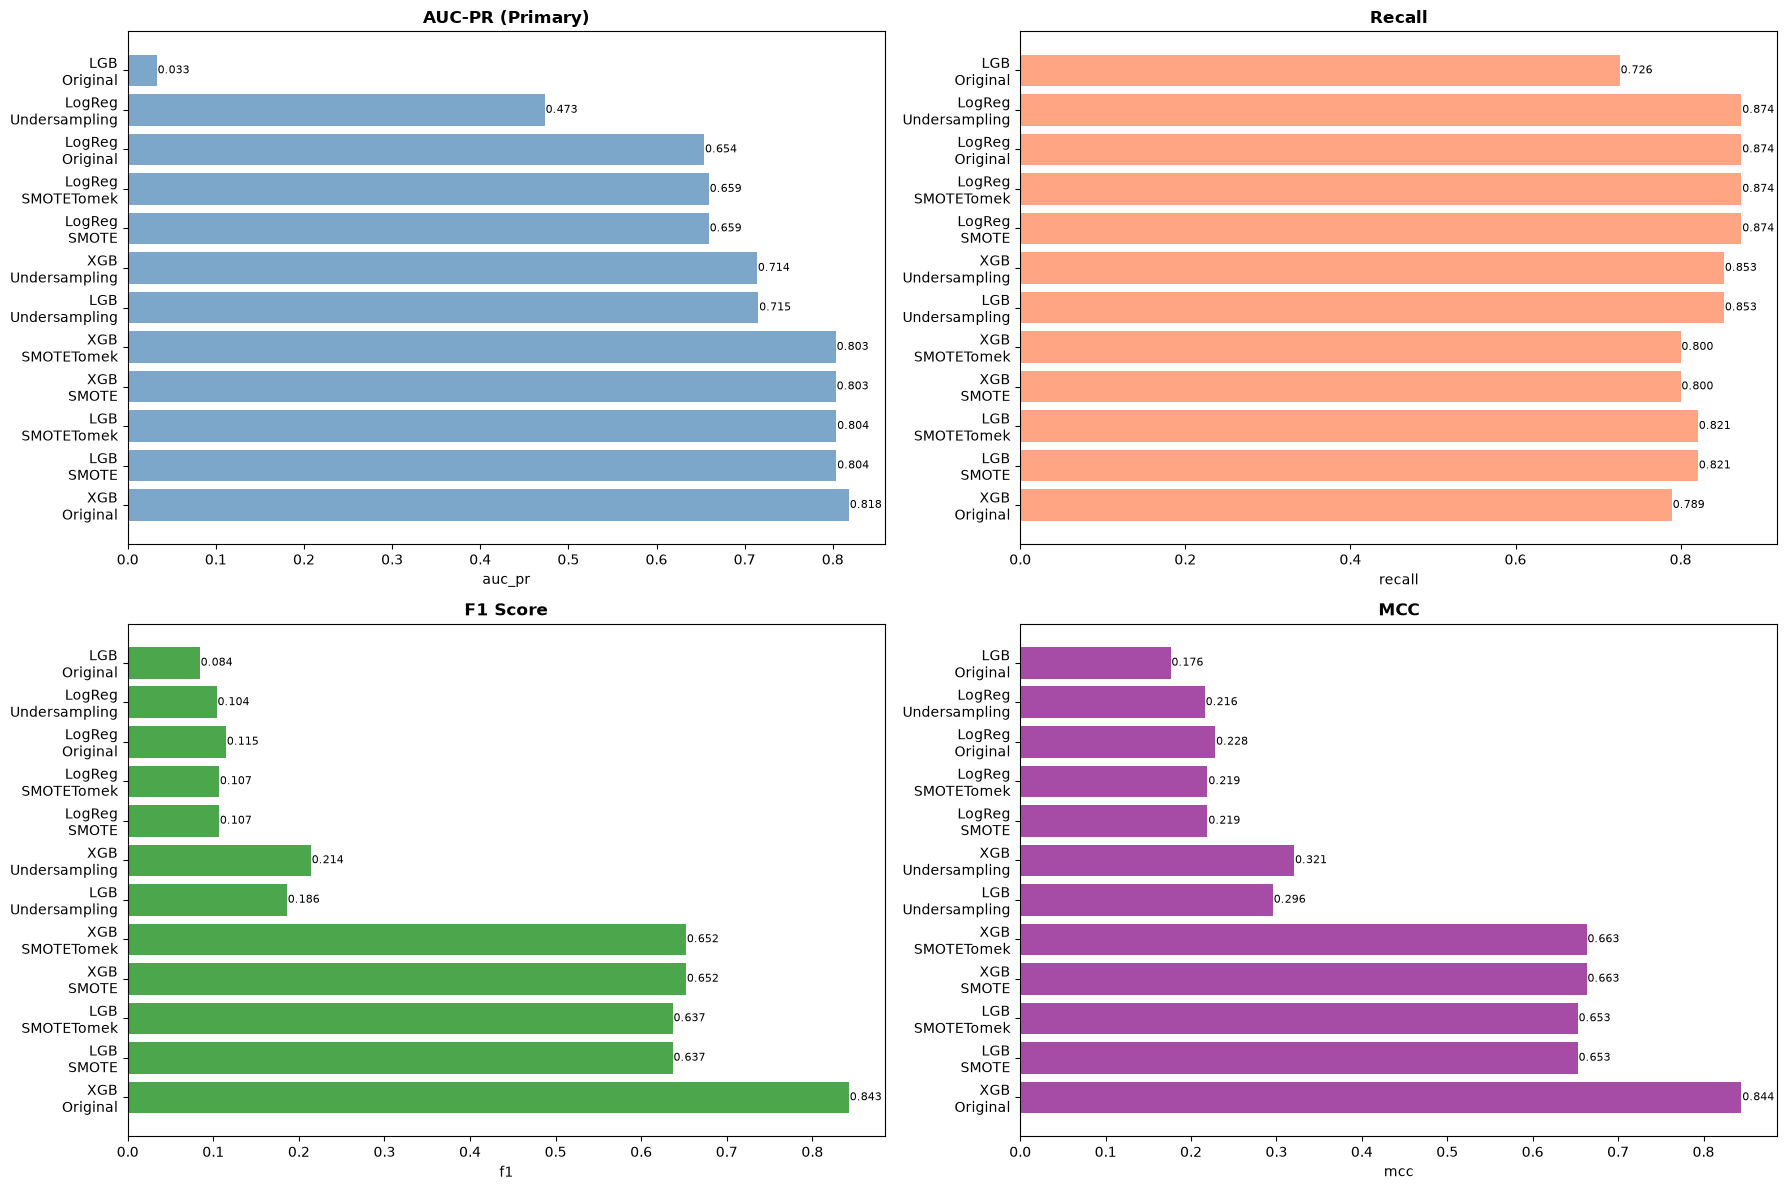

In [10]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics_to_plot = ['auc_pr', 'recall', 'f1', 'mcc']
titles = ['AUC-PR (Primary)', 'Recall', 'F1 Score', 'MCC']
colors = ['steelblue', 'coral', 'green', 'purple']

for i, (metric, title, color) in enumerate(
        zip(metrics_to_plot, titles, colors)):
    ax = axes[i//2, i%2]
    values = results_df[metric].values
    names = [n.replace('_', '\n') for n in results_df.index]

    bars = ax.barh(names, values, color=color, alpha=0.7)
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)

    for bar, val in zip(bars, values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Precision-recall curve for the best performing models.

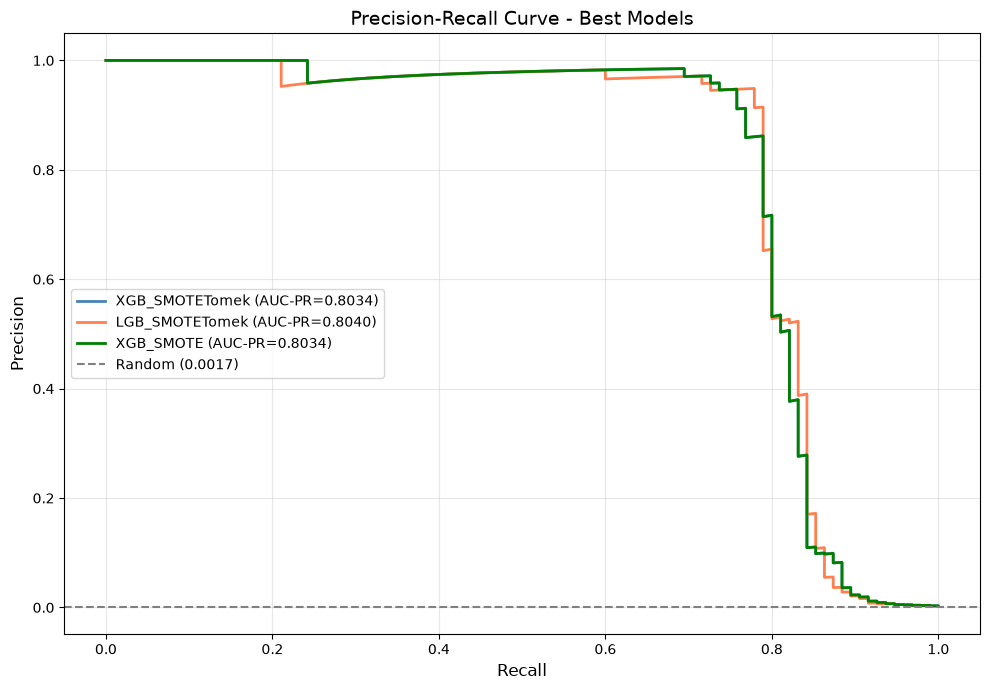

In [11]:
# PR curve for best models
fig, ax = plt.subplots(figsize=(10, 7))

# Retrain best 3 models for PR curve
best_configs = [
    ('XGB_SMOTETomek', xgb.XGBClassifier(n_estimators=300,
        learning_rate=0.05, max_depth=6,
        random_state=42, n_jobs=-1, verbosity=0)),
    ('LGB_SMOTETomek', lgb.LGBMClassifier(n_estimators=300,
        learning_rate=0.05, max_depth=6,
        random_state=42, n_jobs=-1, verbose=-1)),
    ('XGB_SMOTE', xgb.XGBClassifier(n_estimators=300,
        learning_rate=0.05, max_depth=6,
        random_state=42, n_jobs=-1, verbosity=0)),
]

X_smote = pd.read_csv('../data/X_train_smote.csv')
y_smote = pd.read_csv('../data/y_train_smote.csv').squeeze()
X_combined = pd.read_csv('../data/X_train_combined.csv')
y_combined = pd.read_csv('../data/y_train_combined.csv').squeeze()

train_data = {
    'XGB_SMOTETomek': (X_combined, y_combined),
    'LGB_SMOTETomek': (X_combined, y_combined),
    'XGB_SMOTE': (X_smote, y_smote),
}

colors_pr = ['steelblue', 'coral', 'green']

for (name, model), color in zip(best_configs, colors_pr):
    X_tr, y_tr = train_data[name]
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auc_pr = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, color=color, linewidth=2,
            label=f'{name} (AUC-PR={auc_pr:.4f})')

# Random classifier baseline
ax.axhline(y=y_test.mean(), color='gray', linestyle='--',
           label=f'Random ({y_test.mean():.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - Best Models', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Translating the metrics into an estimated dollar cost, using an average fraud amount and a flat cost per false alarm.

In [12]:
# Translate metrics into business language
print("\n" + "="*60)
print("BUSINESS IMPACT ANALYSIS")
print("="*60)

avg_fraud_amount = 122.21

for model_name in results_df.index[:3]:
    # Get fn and fp from all_results directly - not from results_df
    fn = int(all_results[model_name]['fn'])
    fp = int(all_results[model_name]['fp'])
    recall = results_df.loc[model_name, 'recall']

    fraud_loss = fn * avg_fraud_amount
    false_alarm_cost = fp * 5

    print(f"\n{model_name}:")
    print(f"  Frauds missed (FN):     {fn}")
    print(f"  Financial loss:         ${fraud_loss:,.2f}")
    print(f"  False alarms (FP):      {fp}")
    print(f"  False alarm cost:       ${false_alarm_cost:,.2f}")
    print(f"  Total cost:             ${fraud_loss + false_alarm_cost:,.2f}")
    print(f"  Fraud catch rate:       {recall*100:.1f}%")


BUSINESS IMPACT ANALYSIS

XGB_Original:
  Frauds missed (FN):     20
  Financial loss:         $2,444.20
  False alarms (FP):      8
  False alarm cost:       $40.00
  Total cost:             $2,484.20
  Fraud catch rate:       78.9%

LGB_SMOTE:
  Frauds missed (FN):     17
  Financial loss:         $2,077.57
  False alarms (FP):      72
  False alarm cost:       $360.00
  Total cost:             $2,437.57
  Fraud catch rate:       82.1%

LGB_SMOTETomek:
  Frauds missed (FN):     17
  Financial loss:         $2,077.57
  False alarms (FP):      72
  False alarm cost:       $360.00
  Total cost:             $2,437.57
  Fraud catch rate:       82.1%


In [13]:
print(results_df.round(4).to_string())

                      recall  precision      f1  auc_pr  auc_roc     mcc    fn      fp       tn    tp
XGB_Original          0.7895     0.9036  0.8427  0.8183   0.9748  0.8444  20.0     8.0  56643.0  75.0
LGB_SMOTE             0.8211     0.5200  0.6367  0.8040   0.9670  0.6527  17.0    72.0  56579.0  78.0
LGB_SMOTETomek        0.8211     0.5200  0.6367  0.8040   0.9670  0.6527  17.0    72.0  56579.0  78.0
XGB_SMOTE             0.8000     0.5507  0.6524  0.8034   0.9698  0.6631  19.0    62.0  56589.0  76.0
XGB_SMOTETomek        0.8000     0.5507  0.6524  0.8034   0.9698  0.6631  19.0    62.0  56589.0  76.0
LGB_Undersampling     0.8526     0.1044  0.1860  0.7155   0.9758  0.2958  14.0   695.0  55956.0  81.0
XGB_Undersampling     0.8526     0.1224  0.2140  0.7140   0.9825  0.3207  14.0   581.0  56070.0  81.0
LogReg_SMOTE          0.8737     0.0568  0.1067  0.6593   0.9607  0.2192  12.0  1378.0  55273.0  83.0
LogReg_SMOTETomek     0.8737     0.0568  0.1067  0.6593   0.9607  0.2192  12.0  13

Tuning the decision threshold. The default 0.5 threshold is not necessarily the one that minimizes business cost.

In [ ]:
#Threshold Tuning
X_train_orig = pd.read_csv('../data/X_train.csv')
y_train_orig = pd.read_csv('../data/y_train.csv').squeeze()

scale_pos = (y_train_orig==0).sum() / (y_train_orig==1).sum()

best_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    verbosity=0
)
best_model.fit(X_train_orig, y_train_orig)

# Get probabilities on test set
y_prob = best_model.predict_proba(X_test)[:, 1]

# Default threshold = 0.5

print("Default threshold (0.5):")
y_pred_default = (y_prob >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()
print(f"  FN (missed fraud): {fn}")
print(f"  FP (false alarms): {fp}")
print(f"  Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_default):.4f}")


Default threshold (0.5):
  FN (missed fraud): 20
  FP (false alarms): 8
  Precision: 0.9036
  Recall:    0.7895


Sweeping thresholds and picking the one with the lowest total cost.

In [15]:
# Find optimal threshold using cost matrix
avg_fraud_amount = 122.21
false_alarm_cost = 5

thresholds = np.arange(0.01, 0.99, 0.01)
costs = []
recalls = []
precisions = []
f1s = []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_cost = (fn_t * avg_fraud_amount) + (fp_t * false_alarm_cost)
    costs.append(total_cost)
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# Find optimal threshold
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = costs[optimal_idx]

print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: ${min_cost:,.2f}")

# Compare default vs optimal
print("\n" + "="*55)
print(f"{'Metric':<20} {'Default (0.5)':>15} {'Optimal':>15}")
print("="*55)

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
tn_o, fp_o, fn_o, tp_o = confusion_matrix(y_test, y_pred_optimal).ravel()

metrics_compare = {
    'Threshold':  (0.5, optimal_threshold),
    'Recall':     (recall_score(y_test, y_pred_default),
                   recall_score(y_test, y_pred_optimal)),
    'Precision':  (precision_score(y_test, y_pred_default),
                   precision_score(y_test, y_pred_optimal)),
    'F1':         (f1_score(y_test, y_pred_default),
                   f1_score(y_test, y_pred_optimal)),
    'FN':         (fn, fn_o),
    'FP':         (fp, fp_o),
    'Total Cost': (fn*avg_fraud_amount + fp*false_alarm_cost,
                   fn_o*avg_fraud_amount + fp_o*false_alarm_cost),
}

for metric, (default_val, optimal_val) in metrics_compare.items():
    if metric in ['Total Cost']:
        print(f"{metric:<20} ${default_val:>14,.2f} ${optimal_val:>14,.2f}")
    elif metric in ['FN', 'FP']:
        print(f"{metric:<20} {int(default_val):>15} {int(optimal_val):>15}")
    else:
        print(f"{metric:<20} {default_val:>15.4f} {optimal_val:>15.4f}")


Optimal threshold: 0.05
Minimum total cost: $2,275.36

Metric                 Default (0.5)         Optimal
Threshold                     0.5000          0.0500
Recall                        0.7895          0.8316
Precision                     0.9036          0.5524
F1                            0.8427          0.6639
FN                                20              16
FP                                 8              64
Total Cost           $      2,484.20 $      2,275.36


Visualizing the threshold analysis.

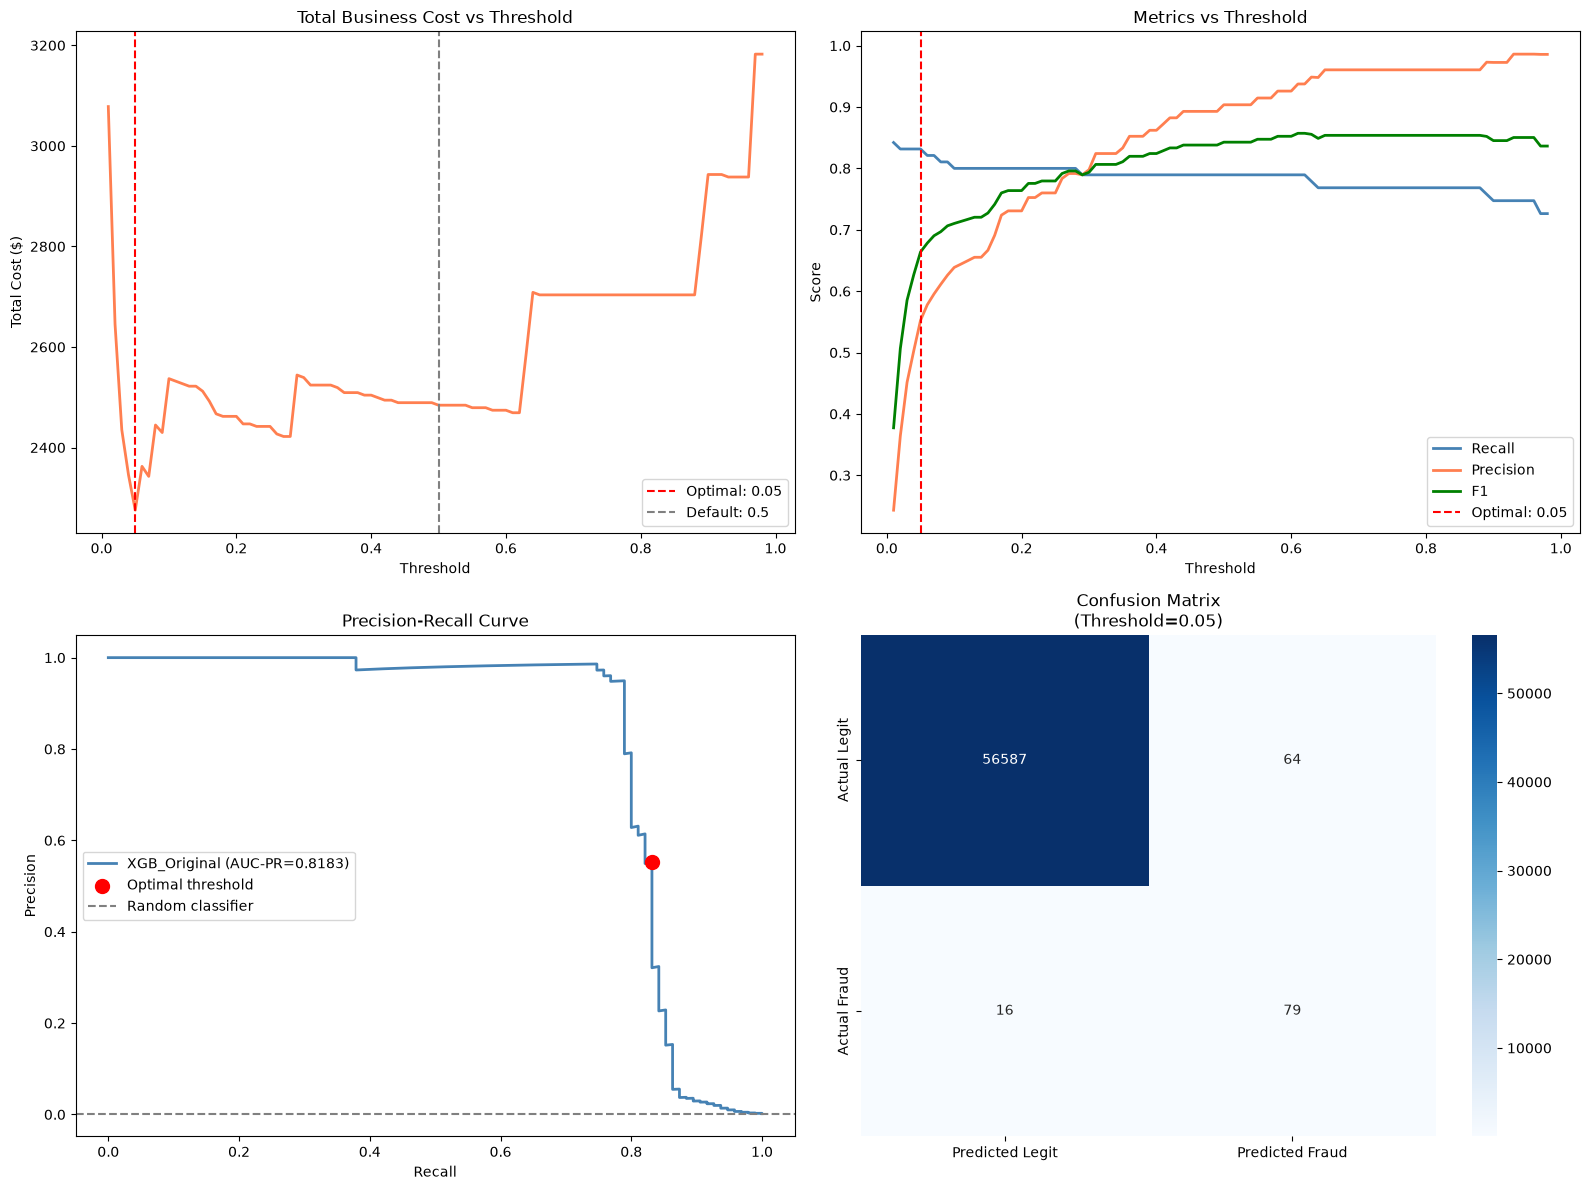


Threshold analysis complete
Optimal threshold: 0.05
Cost reduction: $208.84


In [16]:
# Visualize threshold analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cost vs threshold
axes[0,0].plot(thresholds, costs, color='coral', linewidth=2)
axes[0,0].axvline(x=optimal_threshold, color='red', linestyle='--',
                   label=f'Optimal: {optimal_threshold:.2f}')
axes[0,0].axvline(x=0.5, color='gray', linestyle='--', label='Default: 0.5')
axes[0,0].set_title('Total Business Cost vs Threshold')
axes[0,0].set_xlabel('Threshold')
axes[0,0].set_ylabel('Total Cost ($)')
axes[0,0].legend()

# Precision-Recall vs threshold
axes[0,1].plot(thresholds, recalls, color='steelblue',
               linewidth=2, label='Recall')
axes[0,1].plot(thresholds, precisions, color='coral',
               linewidth=2, label='Precision')
axes[0,1].plot(thresholds, f1s, color='green',
               linewidth=2, label='F1')
axes[0,1].axvline(x=optimal_threshold, color='red',
                   linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
axes[0,1].set_title('Metrics vs Threshold')
axes[0,1].set_xlabel('Threshold')
axes[0,1].set_ylabel('Score')
axes[0,1].legend()

# PR Curve
precision_curve, recall_curve, thresh_curve = precision_recall_curve(
    y_test, y_prob)
auc_pr = average_precision_score(y_test, y_prob)

axes[1,0].plot(recall_curve, precision_curve,
               color='steelblue', linewidth=2,
               label=f'XGB_Original (AUC-PR={auc_pr:.4f})')
axes[1,0].scatter([recall_score(y_test, y_pred_optimal)],
                   [precision_score(y_test, y_pred_optimal)],
                   color='red', s=100, zorder=5, label='Optimal threshold')
axes[1,0].axhline(y=y_test.mean(), color='gray',
                   linestyle='--', label='Random classifier')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend()

# Confusion matrix - optimal threshold
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            ax=axes[1,1])
axes[1,1].set_title(f'Confusion Matrix\n(Threshold={optimal_threshold:.2f})')

plt.tight_layout()
plt.savefig('../results/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nThreshold analysis complete")
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Cost reduction: ${costs[thresholds.tolist().index(0.5)] - min_cost:,.2f}")

Summary of the threshold tuning result.

In [17]:
# Summary of the threshold tuning result
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"At optimal threshold:")
print(f"  Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  FN:        {fn_o}")
print(f"  FP:        {fp_o}")
print(f"  Cost default 0.5:  ${costs[list(thresholds).index(min(thresholds, key=lambda x: abs(x-0.5)))]:,.2f}")
print(f"  Cost optimal:      ${min_cost:,.2f}")



Optimal threshold: 0.05
At optimal threshold:
  Recall:    0.8316
  Precision: 0.5524
  FN:        16
  FP:        64
  Cost default 0.5:  $2,484.20
  Cost optimal:      $2,275.36
